In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
data = pd.read_csv("./winning_deck_results.csv", index_col=0)
# Turn the won column into boolean
data['won'] = data['won'].map({' True': True, " False": False})

In [2]:
visible_cards = data.iloc[:, [2, 9, 17, 20, 24, 27, 29]]
deck_cards = data.iloc[:, 30:]

In [3]:
data.describe()

,num_moves,x0,x1,x2,x3,x4,x5,x6,x7,x8,...,x42,x43,x44,x45,x46,x47,x48,x49,x50,x51
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,...,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,58.485200,26.343500,26.414100,26.556900,26.616500,26.566200,26.531400,26.360500,26.734400,26.16500,...,26.263300,26.90740,26.448000,26.441100,26.441700,26.532300,26.515900,26.510100,26.661200,26.322400
std,39.521622,14.988768,14.881235,14.991859,14.981458,15.025252,15.052364,15.027346,14.980758,15.09299,...,14.984026,15.05653,14.975043,14.942324,15.064843,15.065851,14.940063,15.024835,14.935211,15.052512
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,...,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,29.000000,13.000000,14.000000,14.000000,14.000000,13.000000,13.000000,13.000000,14.000000,13.00000,...,13.000000,14.00000,13.000000,13.000000,13.000000,13.000000,14.000000,14.000000,14.000000,13.000000
50%,47.000000,26.000000,26.000000,27.000000,27.000000,27.000000,27.000000,26.000000,27.000000,26.00000,...,26.000000,27.00000,27.000000,27.000000,26.000000,27.000000,26.000000,26.000000,27.000000,26.000000
75%,75.000000,39.000000,39.000000,40.000000,40.000000,40.000000,40.000000,39.000000,40.000000,39.00000,...,39.000000,40.00000,39.000000,39.000000,39.000000,40.000000,39.000000,40.000000,40.000000,39.000000
max,156.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.00000,...,52.000000,52.00000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000


In [ ]:
data[1]

<Axes: xlabel='won', ylabel='num_moves'>

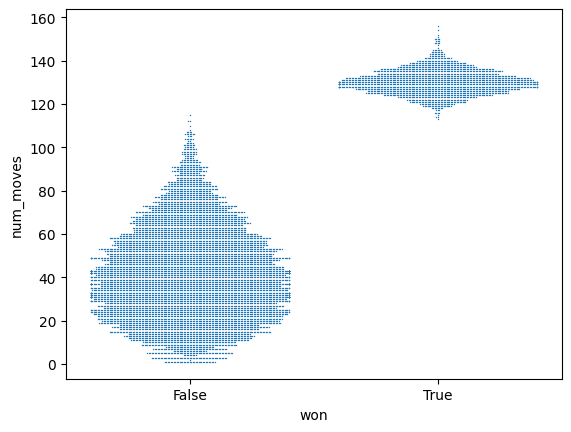

In [4]:
# Do not set size greater than 1. It can't display all points if higher
sns.swarmplot(x=data['won'], y=data['num_moves'], size=1)

In [5]:
max_loss = data.loc[data['won'] == False, 'num_moves'].max()
min_win = data.loc[data['won'] == True, 'num_moves'].min()
print("Maximum moves to loss:", max_loss, " | Minimum moves to win:", min_win)

Maximum moves to loss: 115  | Minimum moves to win: 113


In [ ]:
from sklearn.preprocessing import StandardScaler as StdS
from sklearn.linear_model import LogisticRegression as LReg
from sklearn.neural_network import MLPClassifier as MLP
from sklearn.neighbors import KNeighborsClassifier as KNN
from sklearn.svm import SVC
from sklearn.gaussian_process import GaussianProcessClassifier as GPC
from sklearn.gaussian_process.kernels import RBF
from sklearn.tree import DecisionTreeClassifier as DTree
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.model_selection import cross_val_score
from alive_progress import alive_bar

In [3]:
X = data.iloc[:, 2:].values
y = data.iloc[:, 1].values
sc = StdS()
sc.fit(X)
X_sc = sc.transform(X)

In [10]:
# SVC(gamma=2, C=1),
# GPC(1.0 * RBF(1.0)),
# DTree(max_depth=5),
# RandomForestClassifier(max_depth=5, n_estimators=10, max_features=1),
# MLP(alpha=1, max_iter=1000),
# AdaBoostClassifier(),
# GaussianNB(),
# QDA(),
# LReg(random_state=1, solver='lbfgs')

# K Nearest Neighbors
Change `folds_to_test` and `neighbors_to_test` to modify the tests

In [15]:
folds_to_test: int = 20
neighbors_to_test: int = 128
# K Nearest Neighbors Test
accuracy: float = 0
acc_n: int = 0
acc_f: int = 0
precision: float = 1
pre_n: int = 0
pre_f: int = 0
# Test different folds
with alive_bar((folds_to_test-2)*(neighbors_to_test-3), force_tty=True) as bar:
    for o in range(2, folds_to_test):
        # Test different neighbors
        for i in range(3, neighbors_to_test):
            cvs = cross_val_score(KNN(i), X_sc, y, cv=o, n_jobs=-1)
            mean: float = float(np.mean(cvs))
            std: float = float(np.std(cvs))
            if mean > accuracy:
                accuracy = mean
                acc_n = i
                acc_f = o
            if std < precision:
                precision = std
                pre_n = i
                pre_f = o
            bar()
print("Highest accuracy of", str(accuracy*100) + "% at", acc_n, "neighbors in", acc_f, "folds")
print("Highest precision of", str((1-precision)*100) + "% at", pre_n, "neighbors in", pre_f, "folds")

|████████████████████████████████████████| 2250/2250 [100%] in 13:10.4 (2.85/s) 
Highest accuracy of 81.31000475767634% at 25 neighbors in 7 folds
Highest precision of 100.0% at 18 neighbors in 2 folds


# Linear SVC
Add or remove from `tests_to_run` to change the number of tests

Uses `folds_to_test` from before

In [16]:
tests_to_run = [.0001, .001, .01, .1, 1.0, 10.0]
# Linear SVC Test
accuracy: float = 0
acc_c: float = 0
acc_f: int = 0
precision: float = 1
pre_c: float = 0
pre_f: int = 0
# Test different folds
with alive_bar(len(tests_to_run)*(folds_to_test-2), force_tty=True) as bar:
    for o in range(2, folds_to_test):
        # Test different neighbors
        for i in tests_to_run:
            cvs = cross_val_score(SVC(C=i, kernel="linear"), X_sc, y, cv=o, n_jobs=-1)
            mean: float = float(np.mean(cvs))
            if mean > accuracy:
                accuracy = mean
                acc_c = i
                acc_f = o
            std: float = float(np.std(cvs))
            if std < precision:
                precision = std
                pre_c = i
                pre_f = o
            bar()
print("Highest accuracy of", str(accuracy*100) + "% at", acc_c, "C and", acc_f, "folds.")
print("Highest precision of", str((1-precision)*100) + "% at", pre_c, "C and", pre_f, "folds.")

|████████████████████████████████████████| 108/108 [100%] in 1:27:51.4 (0.02/s) 
Highest accuracy of 81.29004537447325% at 0.0001 C and 19 folds.
Highest precision of 99.99% at 0.0001 C and 2 folds.


# SVC
Change `gamma_to_test` to change the number of tests

Uses `folds_to_test` and `tests_to_run` from before

In [17]:
gamma_to_test: int = 16
# Linear SVC Test
accuracy: float = 0
acc_c: float = 0
acc_g: int = 0
acc_f: int = 0
precision: float = 1
pre_c: float = 0
pre_g: int = 0
pre_f: int = 0
# Test different folds
with alive_bar(len(tests_to_run)*(folds_to_test-2)*gamma_to_test, force_tty=True) as bar:
    for o in range(2, folds_to_test):
        for i in tests_to_run:
            for k in range(gamma_to_test):
                cvs = cross_val_score(SVC(C=i, gamma=gamma_to_test), X_sc, y, cv=o, n_jobs=-1)
                mean: float = float(np.mean(cvs))
                if mean > accuracy:
                    accuracy = mean
                    acc_c = i
                    acc_g = k
                    acc_f = o
                std: float = float(np.std(cvs))
                if std < precision:
                    precision = std
                    pre_c = i
                    pre_g = k
                    pre_f = o
                bar()
print("Highest accuracy of", str(accuracy*100) + "% at", acc_c, "C,", acc_g, "gamma, and", acc_f, "folds.")
print("Highest precision of", str((1-precision)*100) + "% at", pre_c, "C,", pre_g, "gamma, and", pre_f, "folds.")

|▍⚠︎                                      | (!) 14/1728 [1%] in 12.0s (1.20/s)   


KeyboardInterrupt: 